### 📚 Hierarchical Agent Teams

The concept of a single supervisor node to route work between different worker nodes.

But what if the job for a single worker becomes too complex? What if the number of workers becomes too large?

For some applications, the system may be more effective if work is distributed hierarchically.

By composing different sub-graphs and creating a top-level supervisor, along with mid-level supervisors.

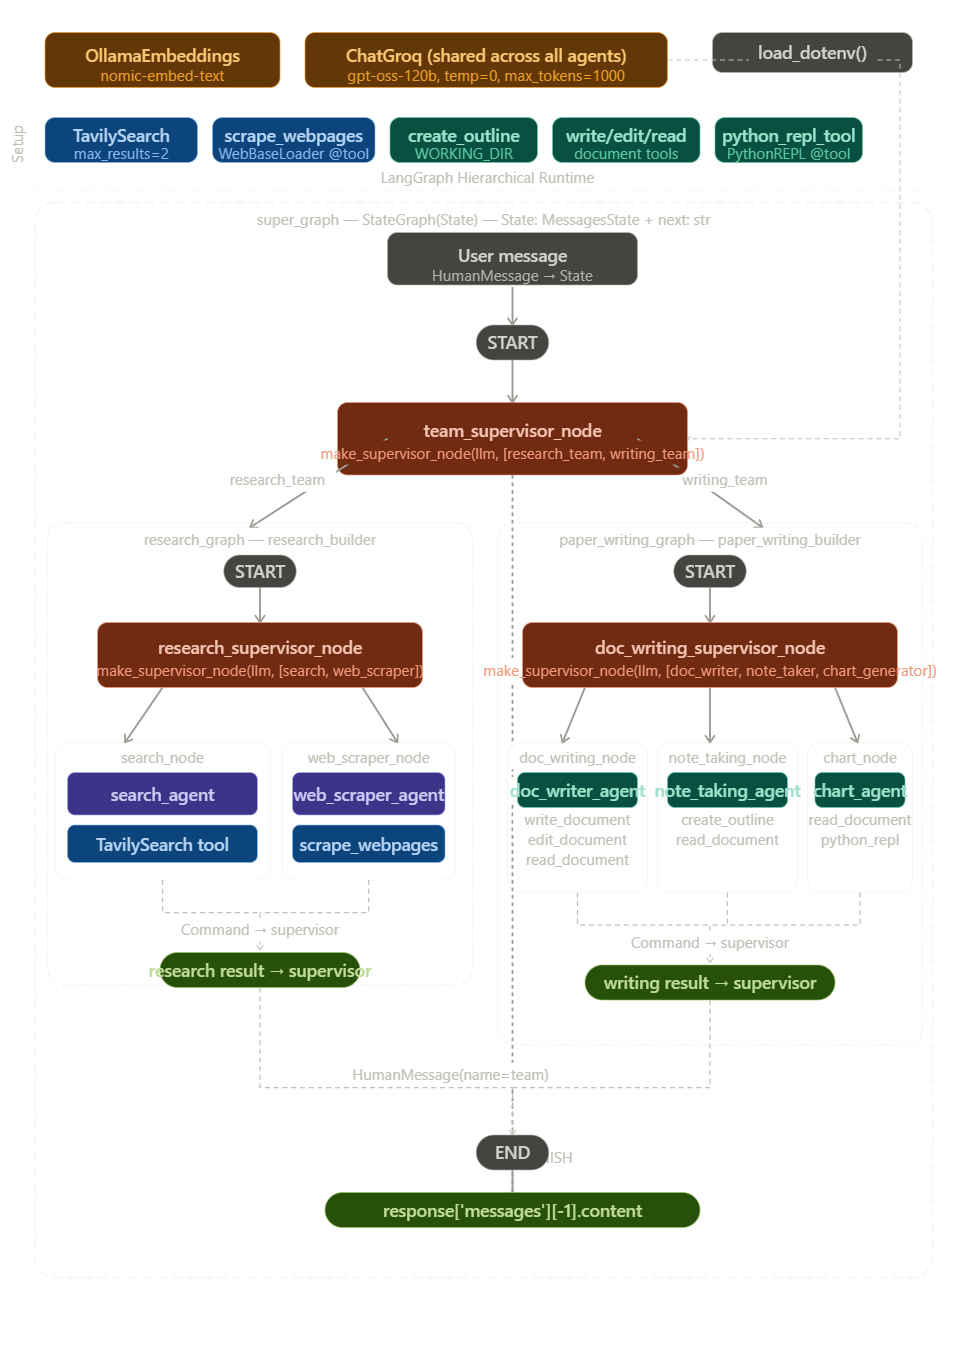

In [2]:
# ------------------------------------------------------------
# 1. LLM and Embeddings 
# ------------------------------------------------------------

from langchain_groq import ChatGroq
from langchain_ollama.embeddings import OllamaEmbeddings
import os
from dotenv import load_dotenv

load_dotenv()
os.environ['GROQ_API_KEY'] = os.getenv('groq_api_key')
os.environ['TAVILY_API_KEY'] = os.getenv('tavily_api_key')

llm = ChatGroq(model='openai/gpt-oss-120b', max_tokens=1000, temperature=0)
embedding = OllamaEmbeddings(model='nomic-embed-text')

In [3]:
# ------------------------------------------------------------
# 2. Search - Tavily
# ------------------------------------------------------------

from langchain_community.document_loaders import WebBaseLoader
from langchain_tavily import TavilySearch
from typing import Annotated, List
from langchain_core.tools import tool

tavily_search = TavilySearch(max_results=2)

@tool
def scrape_webpages(urls: List[str]) -> str:
    """Use requests and bs4 to scrape the provided web pages for detailed information."""
    loader = WebBaseLoader(urls)
    docs = loader.load()
    
    return '\n\n'.join(
        [
            f'<Document name="{doc.metadata.get("title", "")}">\n{doc.page_content}\n</Document>' for doc in docs
        ]
    )

USER_AGENT environment variable not set, consider setting it to identify your requests.


In [ ]:
from pathlib import Path
from tempfile import TemporaryDirectory
from typing import Dict, Optional
from langchain_experimental.utilities import PythonREPL
from typing_extensions import TypedDict

_TEMP_DIRECTORY = TemporaryDirectory()
WORKING_DIRECTORY = Path(_TEMP_DIRECTORY.name)

@tool
def create_outline(
    points: Annotated[List[str], 'List of main points or sections.'],
    file_name: Annotated[str, 'File path to save the outline']
) -> Annotated[str, 'Path of the saved outline file.']:
    """Create and save an outline"""
    
    with (WORKING_DIRECTORY / file_name).open('w') as file:
        for i, path in enumerate(points):
            file.write(f'{i + 1}. {points}\n')
    return f'Outline saved to {file_name}'

@tool
def write_document(
    content: Annotated[str, 'Text content to be written into the document.'],
    file_name: Annotated[str, 'File path to saved the document.']
) -> Annotated[str, 'Path of the saved document file.']:
    """Create and save a text document"""
    
    with (WORKING_DIRECTORY / file_name).open('w') as file:
        file.write(content)
    return f'Document saved to {file_name}'

@tool
def edit_document(
    file_name: Annotated[str, 'Path of the document to be edited.'],
    inserts: Annotated[Dict[int, str], 'Dictionary where key is the line number (1-indexed) and value is the text to be inserted at that line.']
) -> Annotated[str, 'Path of the edited document file.']:
    """Edit a document by inserting text at specific line numbers."""
    
    with (WORKING_DIRECTORY / file_name).open('r') as file:
        lines = file.readlines()
        
    sorted_inserts = sorted(inserts.items())
    
    for line_number, text in sorted_inserts:
        if 1 <= line_number <= len(lines) + 1:
            lines.insert(line_number - 1, text + '\n')
        else:
            return f'Error: Line number {line_number} is out of range.'
        
    with (WORKING_DIRECTORY / file_name).open('w') as file:
        file.writelines(lines)
        
    return f'Document edited and saved to {file_name}'

In [5]:
repl = PythonREPL()

@tool
def python_repl_tool(
    code: Annotated[str, 'The python code to execute to generate the chart.']
):
    """Use this to execute python code. If you want to save the output of a value,
    You should print it out with `print(...)` This is visible to the user."""
    
    try:
        result = repl.run(code)
    except BaseException as e:
        return f'Failed to execute. Error: {repr(e)}'
    
    return f'Successfully executed: \n ```python\n{code}\n```\nStdout: {result}'

In [6]:
from typing import List, Optional, Literal
from langgraph.graph import StateGraph, MessagesState, START, END
from langgraph.types import Command
from langchain_core.messages import HumanMessage, trim_messages

class State(MessagesState):
    next: str

In [7]:
from langchain_core.language_models.chat_models import BaseChatModel

def make_supervisor_node(llm: BaseChatModel, members: list[str]) -> str:
    options = ['FINISH'] + members
    system_prompt = (
        "You are a supervisor tasked with managing a conversation between the"
        f" following workers: {members}. Given the following user request, "
        "respond with the worker to act next. Each worker will perform a "
        "task and respond with their results and status. When finished, "
        "respond with FINISH."
    )
    
    class Router(TypedDict):
        """Worker to route to next. If no workers needed, route to FINISH."""
        
        next: Literal[*options]
        
    def supervisor_node(state: State) -> Command[Literal[*members, '__end__']]:
        """An LLM-based router."""
        
        messages = [
            {'role': 'system', 'content': system_prompt}
        ] + state['messages']
        
        response = llm.with_structured_output(Router).invoke(messages)
        goto = response['next']
        if goto == 'FINISH':
            goto = END
            
        return Command(goto=goto, update={'next': goto})
    
    return supervisor_node

In [8]:
from langchain.agents import create_agent

search_agent = create_agent(llm, tools=[tavily_search])

def search_node(state: State) -> Command[Literal['supervisor']]:
    result = search_agent.invoke(state)
    
    return Command(update={'messages': [HumanMessage(content=result['messages'][-1].content, name='search')]}, goto='supervisor')

# Sub Agent
web_scraper_agent = create_agent(llm, tools=[scrape_webpages])

def web_scraper_node(state: State) -> Command[Literal['supervisor']]:
    result = web_scraper_agent.invoke(state)
    
    return Command(update={'messages': [HumanMessage(content=result['messages'][-1].content, name='web_scraper')]}, goto='supervisor')

research_supervisor_node = make_supervisor_node(llm, ['search', 'web_scraper'])

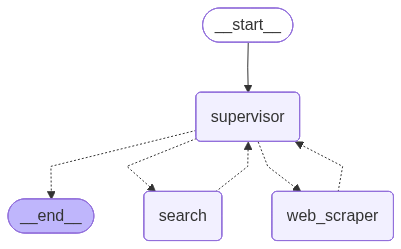

In [9]:
research_builder = StateGraph(State)

research_builder.add_node('supervisor', research_supervisor_node)

research_builder.add_node('search', search_node)
research_builder.add_node('web_scraper', web_scraper_node)

research_builder.add_edge(START, 'supervisor')

research_graph = research_builder.compile()

research_graph

In [14]:
@tool
def read_document(
    file_name: Annotated[str, 'File path to read the document from.'],
    start: Annotated[Optional[int], 'The start line. Default is 0'] = None,
    end: Annotated[Optional[int], 'The end line. Default is None'] = None
) -> str:
    """Read the specified document."""
    
    with (WORKING_DIRECTORY / file_name).open('r') as file:
        lines = file.readlines()
    if start is None:
        start = 0
        
    return '\n'.join(lines[start:end])

doc_writer_agent = create_agent(
    llm,
    tools=[write_document, edit_document, read_document],
    system_prompt=(
        "You can read, write and edit documents based on the note-taker's outlines. "
        "Don't ask follow-up questions."
    )
)

def doc_writing_node(state: State) -> Command[Literal['supervisor']]:
    result = doc_writer_agent.invoke(state)
    return Command(
        update={
            'messages': [HumanMessage(content=result['messages'][-1].content, name='doc_writer')]
        },
       goto='supervisor' 
    )
    
note_taking_agent = create_agent(
    llm,
    tools=[create_outline, read_document],
    system_prompt=(
        "You can read documents and create outlines for the document writer. "
        "Don't ask follow-up questions."
    )
)

def note_taking_node(state: State) -> Command[Literal['supervisor']]:
    result = note_taking_agent.invoke(state)
    return Command(
        update={
            'messages': [HumanMessage(content=result['messages'][-1].content, name='note_taker')]
        },
        goto='supervisor'
    )

chart_generating_agent = create_agent(
    llm,
    tools=[read_document, python_repl_tool]
)

def chart_generating_node(state: State) -> Command[Literal['supervisor']]:
    result = chart_generating_agent.invoke(state)
    return Command(
        update={'messages': [HumanMessage(content=result['messages'][-1].content, name='chart_generator')]},
        goto='supervisor'
    )
    
doc_writing_supervisor_node = make_supervisor_node(llm, ['doc_writer', 'note_taker', 'chart_generator'])

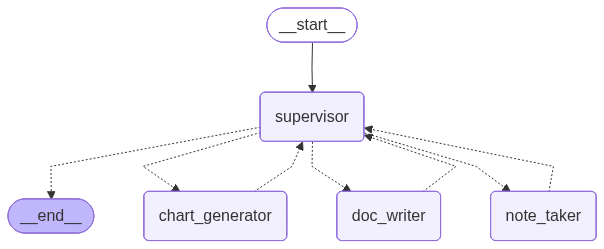

In [15]:
paper_writing_builder = StateGraph(State)

paper_writing_builder.add_node('supervisor', doc_writing_supervisor_node)
paper_writing_builder.add_node('doc_writer', doc_writing_node)
paper_writing_builder.add_node('note_taker', note_taking_node)
paper_writing_builder.add_node('chart_generator', chart_generating_node)

paper_writing_builder.add_edge(START, 'supervisor')

paper_writing_graph = paper_writing_builder.compile()
paper_writing_graph

In [ ]:
team_supervisor_node = make_supervisor_node(llm, ['research_team', 'writing_team'])

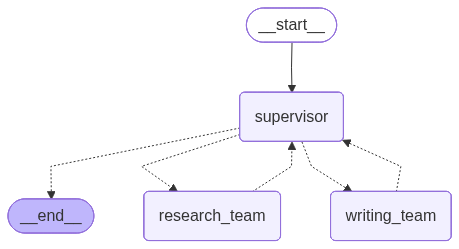

In [20]:
def call_research_team(state: State) -> Command[Literal['supervisor']]:
    response = research_graph.invoke({'messages': state['messages'][-1]})
    return Command(
        update={
            'messages': [HumanMessage(content=response['messages'][-1].content, name='research_team')]
        },
        goto='supervisor'
    )
    
def call_paper_writing_team(state: State) -> Command[Literal['supervisor']]:
    response = paper_writing_graph.invoke({'messages': state['messages'][-1]})
    return Command(
        update={
            'messages': [HumanMessage(content=response['messages'][-1].content, name='writing_team')]
        },
        goto='supervisor'
    )
    
# Define the graph
super_builder = StateGraph(State)

super_builder.add_node('supervisor', team_supervisor_node)
super_builder.add_node('research_team', call_research_team)
super_builder.add_node('writing_team', call_paper_writing_team)

super_builder.add_edge(START, 'supervisor')

super_graph = super_builder.compile()
super_graph

In [21]:
response = super_graph.invoke({'messages': [('user', 'Write about transformer variants in production deployments.')]})

BadRequestError: Error code: 400 - {'error': {'message': 'Tool choice is required, but model did not call a tool', 'type': 'invalid_request_error', 'code': 'tool_use_failed', 'failed_generation': '**Transformer Variants in Production Deployments (2024‑2025)**  \n*A practical guide for engineers, architects, and product leaders*  \n\n---  \n\n## 2. The most common transformer families in production (2024‑2025) – continued  \n\n| Variant | Base model | Params (≈) | Typical use‑case | Core design tricks |\n|---------|------------|------------|------------------|--------------------|\n| **LLaMA‑Adapter‑v2** | LLaMA‑7B/13B | 7‑13\u202fB (full) → 1‑2\u202fB after adapters | Retrieval‑augmented generation, chat‑bots on GPU clusters | Low‑rank adapters\u202f+\u202fLoRA, frozen backbone, prompt‑tuning |\n| **Mistral‑7B‑Instruct‑Distilled** | Mistral‑7B | 7\u202fB → 2‑3\u202fB after distillation | Instruction‑following LLMs, code‑assist, summarisation | Teacher‑student distillation with cross‑en